# High confinement mode
Use the **Python (FAITH labelmaker)** kernel. Change `shot` and `source` below.
Labels use 50 ms bins and 20 rho bins: gray = 0, white = unknown.


In [ ]:
from labeler.events.notebooks import load_shot, plot_shot

shot = 149993
source = "format/shots"
grid = load_shot("high_confinement_mode", shot, source=source)
grid["categories"]

### Original labels
Original annotations before class merging or 50 ms aggregation.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import yaml

from labeler.config import Paths

event, shot = grid["event"], grid["shot"]
root = Paths.from_env().label_tables
manifest = yaml.safe_load((root / "events.yaml").read_text())
spec = next(row for row in manifest["format_datasets"] if row["name"] == event)
raw = {row["stem"]: root / row["path"] for row in manifest["raw_datasets"]}
paths = {stem: raw[stem] for stem in spec["sources"]}
fig, ax = plt.subplots(figsize=(10, 3.5), layout="constrained")
original = pd.read_csv(next(iter(paths.values())))
rows = original.loc[original.Shot == shot]
if rows.empty:
    plt.close(fig)
    print(f"No original confinement annotations for shot {shot}")
else:
    for i, regime in enumerate(["L", "H", "QH", "WP"]):
        selected = rows.loc[rows[regime] == 1]
        bounds = (
            selected[["Confinement Start Time (ms)", "Confinement Stop Time (ms)"]]
            .dropna()
            .to_numpy()
        )
        ax.broken_barh(
            [(start, stop - start) for start, stop in bounds],
            (i - 0.35, 0.7),
            facecolors=["#e69f00", "#2166ac", "#009e73", "#8856a7"][i],
        )
    ax.set(
        yticks=range(4),
        yticklabels=["L", "H", "QH", "WP"],
        xlabel="Time (ms)",
        ylabel="Original regime",
        title=f"Shot {shot} — original confinement intervals",
    )
    plt.show()

### Formatted labels
The saved grid uses 50 ms bins, with each label broadcast over 20 rho bins.

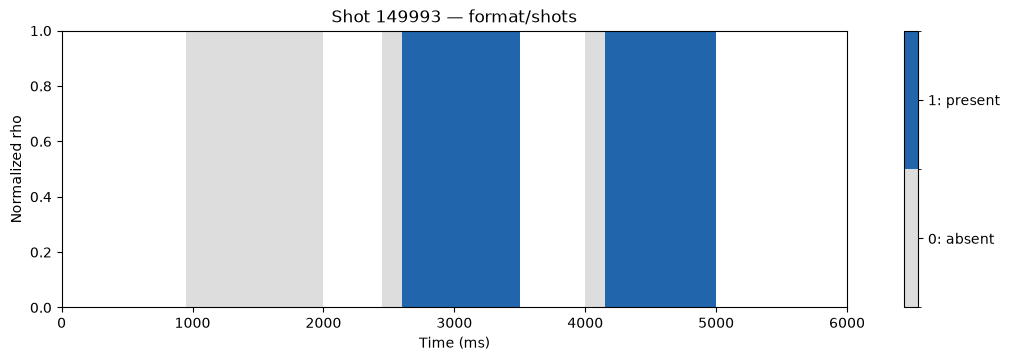

In [3]:
plot_shot(grid);

When extended labels are available, set `source` to `extend_<producer>/<shot-list>`.